In [57]:
%load_ext autoreload
%autoreload 2

from SRC.pairs_trading import PairsBacktest
from SRC.data_loader import DataLoader
from SRC.data_loader import sayields
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
years = 10
tickers = ['GOOGL', 'NVDA', 'MSFT', 'META', 'TSLA']

In [59]:
# load data
loader = DataLoader(years)
loader.market_data(years, tickers)


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


In [60]:
data = loader.data
ticker_a = loader.ticker_a
ticker_b = loader.ticker_b

data['Log_returns_A'] = np.log(data['Price_A'] / data['Price_A'].shift(1))
data['Log_returns_B'] = np.log(data['Price_B'] / data['Price_B'].shift(1))

data = data.dropna()

In [61]:
data

,Price_A,Price_B,Log_A,Log_B,Log_returns_A,Log_returns_B
Date,,,,,,
2016-07-19,1.312050,37.339405,0.271590,3.620049,0.010330,0.000279
2016-07-20,1.329209,37.521290,0.284584,3.624909,0.012994,0.004859
2016-07-21,1.304695,37.388962,0.265969,3.621376,-0.018615,-0.003533
2016-07-22,1.340242,37.630318,0.292850,3.627810,0.026881,0.006435
2016-07-25,1.365002,37.543098,0.311156,3.625490,0.018306,-0.002320
...,...,...,...,...,...,...
2026-07-07,196.929993,367.029999,5.282848,5.905444,0.007032,0.001554
2026-07-08,204.119995,361.920013,5.318708,5.891423,0.035860,-0.014020
2026-07-09,202.779999,358.890015,5.312122,5.883016,-0.006586,-0.008407


In [62]:
beta = np.zeros(len(data))
window = 20  # Define the rolling window size

for t in range(window, len(data)):
    X = data["Log_B"].iloc[t-window:t].values.reshape(-1, 1)
    y = data["Log_A"].iloc[t-window:t].values.reshape(-1, 1)

    lr = LinearRegression()
    lr.fit(X, y)
    beta[t] = lr.coef_[0][0]
data['Beta'] = beta

In [63]:
# standardize the data
data['Log_returns_A_standardized'] = (data['Log_returns_A'] - data['Log_returns_A'].mean()) / data['Log_returns_A'].std()
data['Log_returns_B_standardized'] = (data['Log_returns_B'] - data['Log_returns_B'].mean()) / data['Log_returns_B'].std()

findfont: Font family 'Zapf Humanist Regular' not found.
findfont: Font family 'Zapf Humanist Regular' not found.
findfont: Font family 'Zapf Humanist Regular' not found.
findfont: Font family 'Zapf Humanist Regular' not found.
findfont: Font family 'Zapf Humanist Regular' not found.


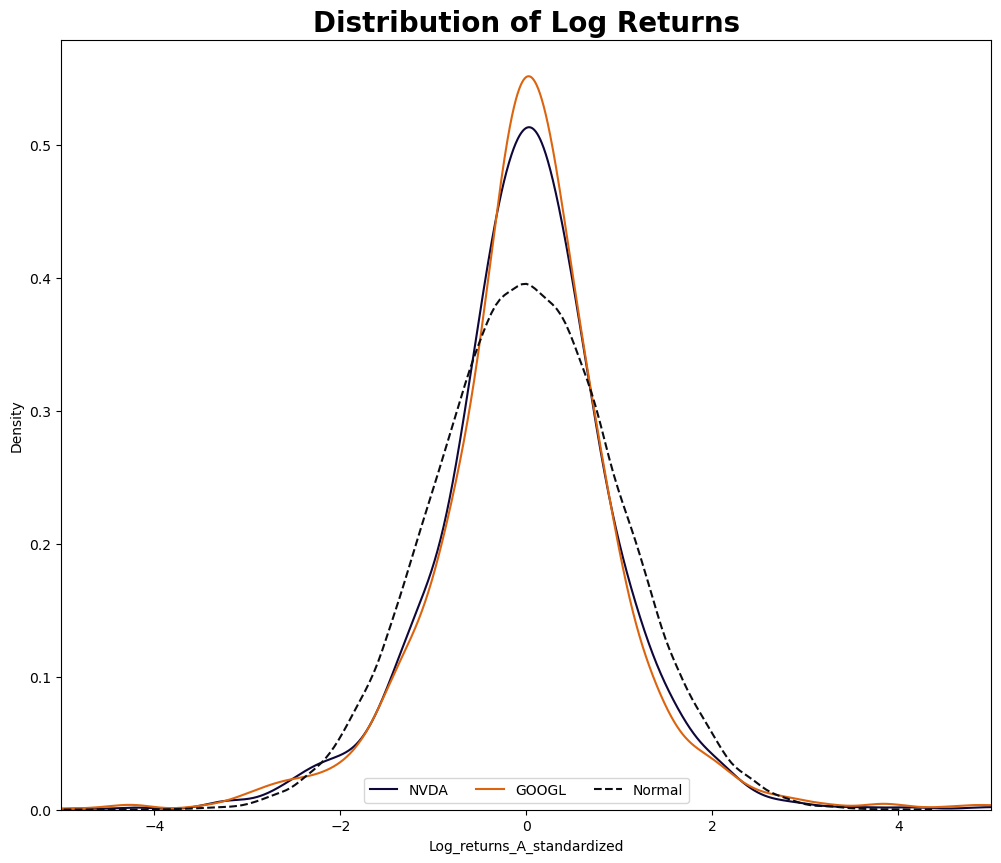

In [64]:

# Plot the Distributions
plt.figure(figsize=(12,10))
sns.kdeplot(data['Log_returns_A_standardized'], label=f"{ticker_a}", color="#0E0739",gridsize = 3000)
sns.kdeplot(data['Log_returns_B_standardized'], label=f"{ticker_b}", color="#DC640E",gridsize = 3000)
sns.kdeplot(np.random.normal(size=100000), label="Normal", color='#0B0D13', linestyle="--")
#plt.xticks(range(-5, 6))
plt.legend(loc=8, ncol=5)
plt.title('Distribution of Log Returns',
          loc='center', fontsize=20, fontweight="bold", fontname="Zapf Humanist Regular")
plt.xlim(-5, 5)
plt.show()

In [65]:
from scipy import stats
from scipy.stats import jarque_bera
# Calculate log returns
data_a = np.log(data['Price_A'] / data['Price_A'].shift(1)).dropna()
data_b = np.log(data['Price_B'] / data['Price_B'].shift(1)).dropna()

print('Jarque-Bera Test Statistics:')
print(f'Jarque-Bera for {ticker_a} is {int(stats.jarque_bera(data_a)[0])}')
print(f'Jarque-Bera for {ticker_b} is {int(stats.jarque_bera(data_b)[0])}')

print('')
# Test for normality
shapiro_test_data_a = stats.shapiro(data_a)
shapiro_test_data_b = stats.shapiro(data_b)

print('-'*30)
print(' ')
print('Shapiro-Wilk Test') 
print("Shapiro W for {0} is {1}".format(ticker_a, shapiro_test_data_a.statistic))
print("Shapiro W for {0} is {1}".format(ticker_b, shapiro_test_data_b.statistic))


Jarque-Bera Test Statistics:
Jarque-Bera for NVDA is 4365
Jarque-Bera for GOOGL is 2125

------------------------------
 
Shapiro-Wilk Test
Shapiro W for NVDA is 0.9439022960497324
Shapiro W for GOOGL is 0.9451614130327493
